# Análise Exploratória de Dados Financeiros (EDA)

O objetivo deste notebook é analisar os retornos diários de algumas ações da B3 (PETR4, VALE3, ITUB4, MGLU3) e comparar com o Ibovespa (^BVSP). 

Passos da análise:
- Estatísticas básicas (Média, Mediana, Volatilidade e Sharpe)
- Formato da distribuição (Assimetria e Curtose)
- Gráficos (Histograma e Boxplot)
- Correlação e Covariância entre os ativos

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ticker = ['PETR4.SA', 'VALE3.SA', 'ITUB4.SA', 'MGLU3.SA', '^BVSP']

In [3]:
dados = yf.download(ticker, start='2019-01-01', end='2024-01-01')

[*********************100%***********************]  5 of 5 completed


## Preparação dos Dados (Preços e Retornos)

Nesta etapa, foi pego apenas o preço de fechamento de cada ação e calculamos a variação percentual diária (os retornos). 

Essa transformação é necessária porque na análise financeira comparamos o rendimento percentual diário dos ativos, e não o preço bruto em reais. Também apagamos o primeiro dia da lista, pois ele não tem um dia anterior para calcular a variação.

In [4]:
precos = dados['Close']
precos.head(3)

Ticker,ITUB4.SA,MGLU3.SA,PETR4.SA,VALE3.SA,^BVSP
Date,,,,,
2019-01-02,20.660423,49.405270,6.287681,26.857456,91012.0
2019-01-03,21.001045,48.876659,6.441867,25.758764,91564.0
2019-01-04,20.649267,47.389111,6.460159,27.435709,91841.0


In [5]:
retornos = precos.pct_change().dropna()
retornos.head(3)

Ticker,ITUB4.SA,MGLU3.SA,PETR4.SA,VALE3.SA,^BVSP
Date,,,,,
2019-01-03,0.016487,-0.010699,0.024522,-0.040908,0.006065
2019-01-04,-0.016751,-0.030435,0.002840,0.065102,0.003025
2019-01-07,0.001893,0.015527,0.015777,-0.005365,-0.001546


In [6]:
retornos.describe()

Ticker,ITUB4.SA,MGLU3.SA,PETR4.SA,VALE3.SA,^BVSP
count,1240.000000,1240.000000,1240.000000,1240.000000,1240.000000
mean,0.000340,0.000106,0.001550,0.000980,0.000453
std,0.020713,0.042442,0.028368,0.025322,0.016625
min,-0.179643,-0.228310,-0.296978,-0.245592,-0.147797
25%,-0.011287,-0.022862,-0.011255,-0.011917,-0.007319
50%,0.000000,-0.001606,0.001459,0.000243,0.000613
75%,0.011908,0.020730,0.015479,0.012702,0.009093
max,0.110592,0.251429,0.222222,0.213579,0.139082


In [7]:
VA = retornos.std() * np.sqrt(252)
VA

Ticker
ITUB4.SA    0.328811
MGLU3.SA    0.673745
PETR4.SA    0.450324
VALE3.SA    0.401982
^BVSP       0.263916
dtype: float64

In [8]:
IQR = retornos.quantile(0.75) - retornos.quantile(0.25)
IQR

Ticker
ITUB4.SA    0.023195
MGLU3.SA    0.043592
PETR4.SA    0.026734
VALE3.SA    0.024619
^BVSP       0.016413
dtype: float64

## 1. Assimetria e Curtose

Calculando a assimetria (skew) e a curtose (kurt) para entender como os retornos se comportam em comparação com uma distribuição normal.

In [9]:
retornos.skew()

Ticker
ITUB4.SA   -0.374759
MGLU3.SA    0.342893
PETR4.SA   -1.262758
VALE3.SA   -0.043620
^BVSP      -1.009616
dtype: float64

In [10]:
retornos.kurt()

Ticker
ITUB4.SA     6.959960
MGLU3.SA     5.087266
PETR4.SA    18.860677
VALE3.SA    15.279964
^BVSP       17.766998
dtype: float64

**Análise dos números:**
- **Curtose alta:** Como a curtose deu bem acima de 0 em todos, significa que existem muitos dias de variação extrema (caudas pesadas).
- **Assimetria negativa:** Ativos como PETR4 e Ibovespa têm assimetria negativa, indicando que as quedas pontuais tendem a ser mais fortes que as altas.

In [11]:
taxa_livre_risco = 0.08
retorno_anualizado = retornos.mean() * 252
sharpe_anualizado = (retorno_anualizado - taxa_livre_risco) / VA
sharpe_anualizado

Ticker
ITUB4.SA    0.017235
MGLU3.SA   -0.079277
PETR4.SA    0.689574
VALE3.SA    0.415573
^BVSP       0.129522
dtype: float64

## 2. Tabela Resumo das Métricas

Aqui juntei as principais estatísticas dos retornos diários e anualizados, além do Índice de Sharpe para ver o retorno ajustado ao risco.

In [12]:
resumo = pd.DataFrame({
                      'Média Diária': retornos.mean(),
                      'Mediana Diária': retornos.median(),
                      'Volatilidade Diária(std)': retornos.std(),
                      'Volatilidade Anualizada': VA,
                      'Amplitude Interquartil': IQR,
                      'Assimetria': retornos.skew(),
                      'Curtose' : retornos.kurt(),
                      'Sharpe Anualizado': sharpe_anualizado
                     })

In [13]:
resumo.rename_axis(None)

,Média Diária,Mediana Diária,Volatilidade Diária(std),Volatilidade Anualizada,Amplitude Interquartil,Assimetria,Curtose,Sharpe Anualizado
ITUB4.SA,0.000340,0.000000,0.020713,0.328811,0.023195,-0.374759,6.959960,0.017235
MGLU3.SA,0.000106,-0.001606,0.042442,0.673745,0.043592,0.342893,5.087266,-0.079277
PETR4.SA,0.001550,0.001459,0.028368,0.450324,0.026734,-1.262758,18.860677,0.689574
VALE3.SA,0.000980,0.000243,0.025322,0.401982,0.024619,-0.043620,15.279964,0.415573
^BVSP,0.000453,0.000613,0.016625,0.263916,0.016413,-1.009616,17.766998,0.129522


**O que dá pra notar aqui:**
- A MGLU3 tem a maior volatilidade do grupo (oscila muito mais no dia a dia).
- O Sharpe Anualizado ajuda a comparar qual ativo entregou melhor retorno em relação ao risco que correu.

## 3. Histogramas dos Retornos

Plotando a distribuição dos retornos da PETR4 e do Ibovespa lado a lado para ver o formato da curva.

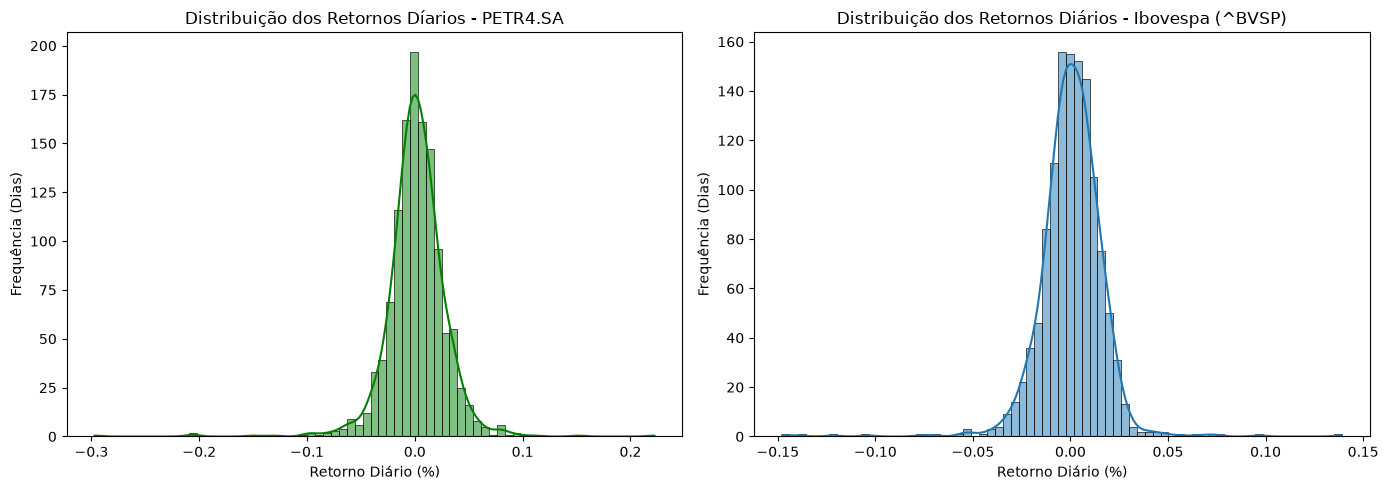

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))

x = retornos['PETR4.SA']
sns.histplot(x, kde=True, color = 'g', ax = ax1)
ax1.set_title('Distribuição dos Retornos Díarios - PETR4.SA')
ax1.set_xlabel('Retorno Diário (%)')
ax1.set_ylabel('Frequência (Dias)')

y = retornos['^BVSP']
sns.histplot(y, kde=True, ax = ax2)
ax2.set_title('Distribuição dos Retornos Diários - Ibovespa (^BVSP)')
ax2.set_xlabel('Retorno Diário (%)')
ax2.set_ylabel('Frequência (Dias)')

plt.tight_layout()
plt.show()

## 4. Boxplot Comparativo

Gráfico para visualizar a variação dos ativos e identificar os outliers (dias de grandes choques no mercado).

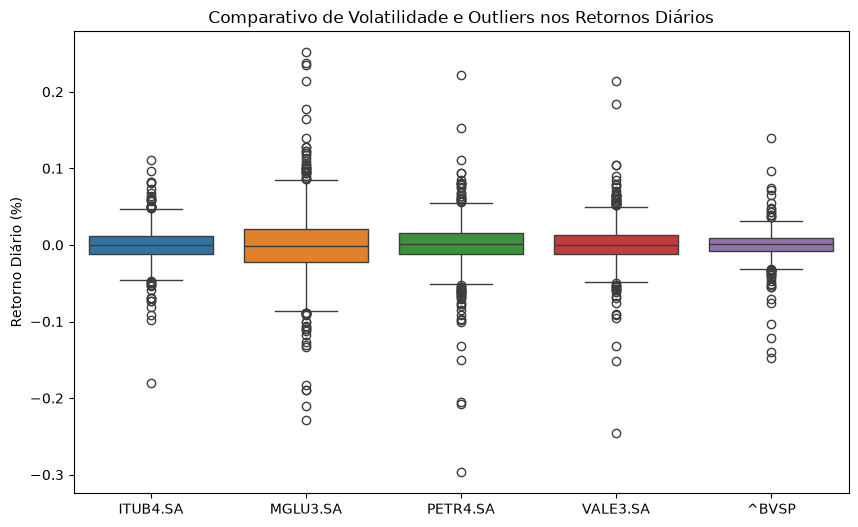

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(retornos)
plt.title('Comparativo de Volatilidade e Outliers nos Retornos Diários')
plt.ylabel('Retorno Diário (%)')
plt.xlabel('')
plt.show()

**Observações:**
- A caixa da MGLU3 é mais larga, mostrando maior variação no dia a dia.
- Os pontos fora das hastes são os outliers (dias com variações atípicas de mercado).

## 5. Correlação de Pearson e Covariância

Calculando a matriz de correlação para ver quais ações andam juntas e a covariância para medir a variação conjunta.

In [16]:
matriz_correlacao = retornos.corr().rename_axis(None)
matriz_correlacao

Ticker,ITUB4.SA,MGLU3.SA,PETR4.SA,VALE3.SA,^BVSP
ITUB4.SA,1.000000,0.327234,0.526526,0.348510,0.755358
MGLU3.SA,0.327234,1.000000,0.295592,0.229329,0.553407
PETR4.SA,0.526526,0.295592,1.000000,0.465096,0.756193
VALE3.SA,0.348510,0.229329,0.465096,1.000000,0.620460
^BVSP,0.755358,0.553407,0.756193,0.620460,1.000000


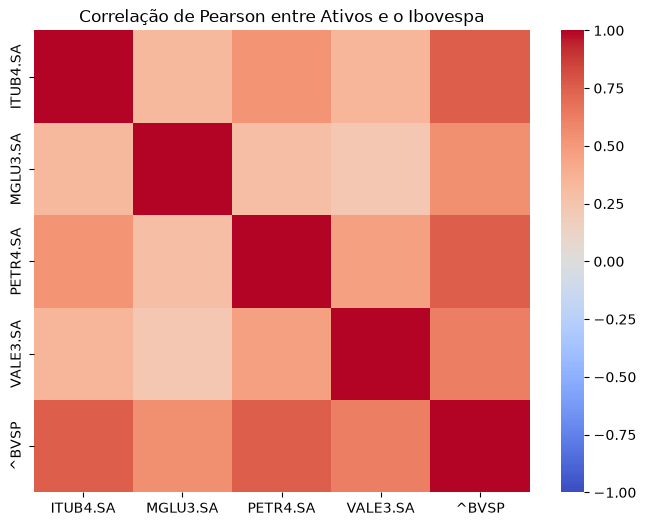

In [17]:
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacao, vmin=-1, vmax=1, fmt='.2f', cmap='coolwarm')
plt.title('Correlação de Pearson entre Ativos e o Ibovespa')
plt.xlabel('')
plt.show()

In [18]:
matriz_covariancia = retornos.cov()
matriz_covariancia.rename_axis(None)

Ticker,ITUB4.SA,MGLU3.SA,PETR4.SA,VALE3.SA,^BVSP
ITUB4.SA,0.000429,0.000288,0.000309,0.000183,0.000260
MGLU3.SA,0.000288,0.001801,0.000356,0.000246,0.000390
PETR4.SA,0.000309,0.000356,0.000805,0.000334,0.000357
VALE3.SA,0.000183,0.000246,0.000334,0.000641,0.000261
^BVSP,0.000260,0.000390,0.000357,0.000261,0.000276


**Sobre a covariância:**
A covariância mostra a direção da relação entre dois ativos (positiva ou negativa), mas sua magnitude não é diretamente comparável entre pares, porque depende da escala de variância de cada ativo — por isso a MGLU3, que tem a maior volatilidade do grupo, aparece com covariâncias mais altas mesmo quando a relação não é necessariamente mais forte. Para comparar a força da relação entre pares diferentes, a correlação (que é a covariância padronizada) é a métrica mais adequada — por isso ela foi o foco da análise acima.

## Conclusão

- Ações individuais são bem mais voláteis e têm mais riscos de dias extremos do que o índice Ibovespa, o que já era esperado, já que o índice diversifica esse risco entre várias empresas.
- Ativos com menor correlação entre si (como MGLU3 e VALE3) são interessantes para montar uma carteira mais diversificada.
- Os dados mostram que retornos financeiros não seguem uma distribuição normal perfeita por conta dos eventos extremos. Parte disso se explica pelo período analisado (2019–2024), que inclui a crise da Covid-19 em 2020 — um choque de mercado que gerou dias de variação muito acima do normal e ajuda a explicar a curtose alta e os outliers vistos nos boxplots.
- Isso reforça um ponto importante em análise de risco: eventos extremos ("caudas gordas") acontecem com mais frequência do que uma distribuição normal preveria, e ignorar isso pode subestimar o risco real de uma carteira.